In [49]:
import pandas as pd
import os
import numpy as np
import json
import collections

In [50]:
with open('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/TSPY_Plus_Flanking/TSPY_Upstream_Motif_hits_Jan202026.json') as json_file:
    dataDict = json.load(json_file)

In [44]:
clusterNetworkDF=pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/TSPY_Plus_Flanking/TSPY_Upstream_Motif_Groupings_Jan202026.csv")

In [45]:
clusterNetworkDF['Start']=[int(x.split(":")[1].split("-")[0]) for x in clusterNetworkDF['Unnamed: 0']]

In [47]:
clusterNetworkDF

,Unnamed: 0,SequenceCluster,cluster,color,Start,Gene
0,HG01261_chrY:5986924-5989714,SeqPromoter:1,1,#7b3f00,5986924,TSPY
1,HG01261_chrY:9028941-9031737,SeqPromoter:2,0,#f401c2,9028941,TSPY
2,HG01261_chrY:9049253-9052049,SeqPromoter:3,0,#fa00dd,9049253,TSPY
3,HG01261_chrY:9069577-9072391,SeqPromoter:4,0,#fcba03,9069577,TSPY
4,HG01261_chrY:9089869-9092665,SeqPromoter:5,0,#33a02c,9089869,TSPY
...,...,...,...,...,...,...
3500,HG02572_chrY:9420519-9423315,SeqPromoter:90,0,#33a02c,9420519,TSPY
3501,HG02572_chrY:9440804-9443598,SeqPromoter:34,0,#76b027,9440804,TSPY
3502,HG02572_chrY:9481410-9484206,SeqPromoter:52,0,#33a02c,9481410,TSPY
3503,HG02572_chrY:9501725-9504537,SeqPromoter:26,0,#1f78b4,9501725,TSPY


In [46]:
clusterNetworkDF['Gene']='TSPY'

In [22]:
clusterNetworkDFRBMY = pd.read_csv("/rbmy.csv").drop(columns=['Unnamed: 0.1'])

In [31]:
rbmyDict={0:'Pink', 1:'Lime'}
tspyDict={0:'Purple', 1:'Teal'}

In [32]:
clusterNetworkDF["cluster"] = clusterNetworkDF["cluster"].map(tspyDict)
clusterNetworkDFRBMY["cluster"] = clusterNetworkDFRBMY["cluster"].map(rbmyDict)

In [35]:
combinedClusterDF = pd.concat([clusterNetworkDF, clusterNetworkDFRBMY])

In [40]:
combinedClusterDF[['Unnamed: 0','cluster','color','Gene']].to_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/TSPY_RBMY_Clusters.csv")

In [5]:
#cluster1 blue , cluster 0 = pink

In [6]:
#clusterNetworkDF[clusterNetworkDF['Unnamed: 0'].str.contains("NA18879")]

In [7]:
#clusterNetworkDF[clusterNetworkDF['Unnamed: 0'].str.contains("NA18879")]

In [8]:
#Randomly selected copies as representatitives
newDFList=[]
for sublist in dataDict['SeqPromoter:1']['plus']:
    sublist.append('SeqPromoter:1')
    newDFList.append(sublist)
#for sublist in dataDict['SeqPromoter:1']['minus']:
#    sublist.append('SeqPromoter:1')
#    newDFList.append(sublist)  

for sublist in dataDict['SeqPromoter:2']['plus']:
    sublist.append('SeqPromoter:2')
    newDFList.append(sublist)
#for sublist in dataDict['SeqPromoter:2']['minus']:
#    sublist.append('SeqPromoter:2')
#    newDFList.append(sublist)    

for sublist in dataDict['SeqPromoter:31']['plus']:
    sublist.append('SeqPromoter:31')
    newDFList.append(sublist)
#for sublist in dataDict['SeqPromoter:31']['minus']:
#    sublist.append('SeqPromoter:31')
#    newDFList.append(sublist)    

In [9]:
newDF = pd.DataFrame(data=newDFList)
newDF['NewStart']=[2000-x for x in newDF[0]]
newDF['NewEnd']=[2000-x for x in newDF[1]]
newDF.sort_values(by=['NewStart'], inplace=True)

cols = {0:"Start_raw", 1:"End_raw", 2:"Strand", 3:"TF", 4:"JasparID",
        5:"Unused1", 6:"Motif", 7:"MotifRC", 8:"SeqCol1", 9:"SeqCol2", 10:"SeqCol3",'NewStart':'NewStart','NewEnd':'NewEnd'}
newDF = newDF.rename(columns=cols)

In [10]:
group1=newDF[newDF['SeqCol1']=='SeqPromoter:1'].copy() #blue
#group2=newDF[newDF['SeqCol1']=='SeqPromoter:31'].copy() #teal
group3=newDF[newDF['SeqCol1']=='SeqPromoter:2'].copy() #pink

In [11]:
print(set(group1['TF'])-set(group3['TF']))
print(len(set(group1['TF'])))
print(len(set(group1['TF'])-set(group3['TF'])))

{'NR2C1', 'GSX1', 'BSX', 'HOXB8', 'NEUROG2', 'HOXD8', 'NKX6-2', 'SNAI1', 'HOXB3', 'HAND2', 'BARX1', 'NKX6-3', 'TEAD2', 'GSX2', 'HOXA6', 'Atoh1', 'HOXA7', 'NR2C2', 'Hand1::Tcf3', 'ASCL1'}
53
20


In [13]:
print(set(group3['TF'])-set(group1['TF']))
print(len(set(group3['TF'])))
print(len(set(group3['TF'])-set(group1['TF'])))

{'HOXB6', 'ZNF331', 'RELB', 'FIGLA', 'ZNF317', 'ZEB1', 'TFAP2E', 'ZNF549'}
41
8


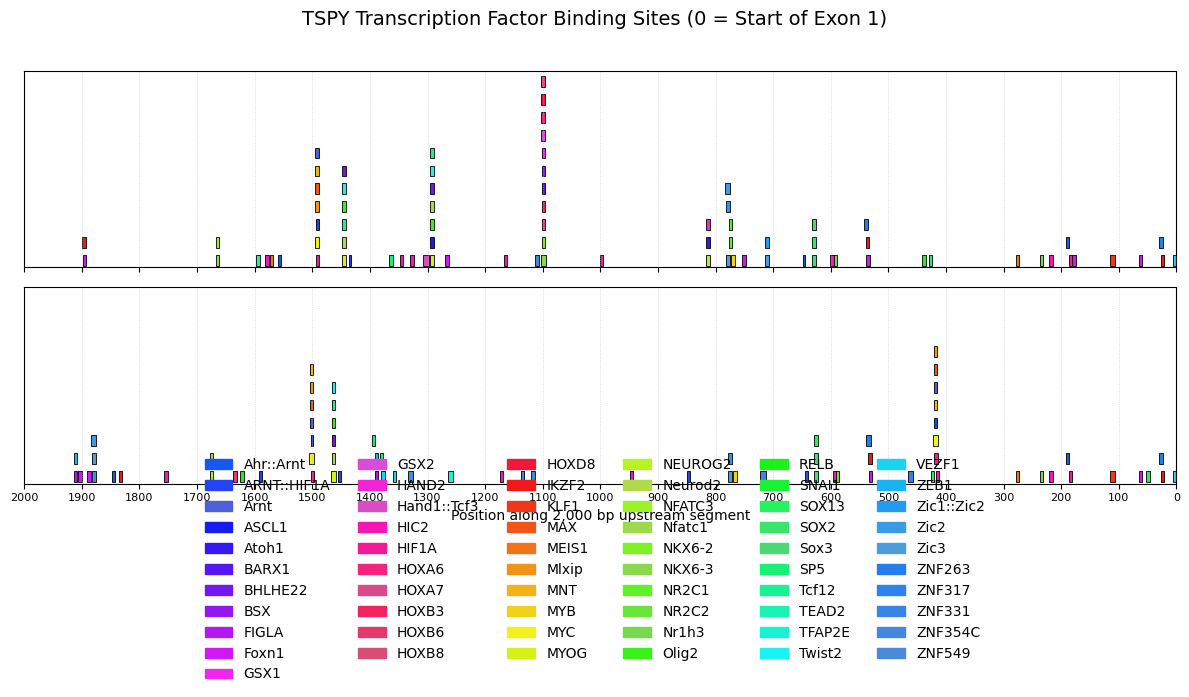

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import re, colorsys
from collections import defaultdict

dfs = [group1, group3]

all_tfs_series = pd.concat([df["TF"].astype(str).dropna() for df in dfs])
all_tfs_unique = sorted(all_tfs_series.unique().tolist())

def tf_stem(name: str, maxlen: int = 4) -> str:
    m = re.match(r"[A-Za-z]+", name)  
    if not m:
        return name.upper()
    return m.group(0).upper()[:maxlen]

stem_to_tfs = defaultdict(list)
for tf in all_tfs_unique:
    stem_to_tfs[tf_stem(tf)].append(tf)

for stem in stem_to_tfs:
    stem_to_tfs[stem] = sorted(stem_to_tfs[stem])

stems = sorted(stem_to_tfs.keys())
n_stems = max(1, len(stems))

phi = (1 + 5 ** 0.5) / 2
base_hues = [(i / n_stems + 1 / phi) % 1.0 for i in range(n_stems)]
stem_to_hue = {stem: base_hues[i] for i, stem in enumerate(stems)}

def nth_shade(h, k, K):
    if K == 1:
        s, v = 0.90, 0.95
    else:
        s = 0.85 - 0.20 * (k / max(1, K - 1))   # 0.85 → 0.65
        v = 0.95 - 0.10 * (k / max(1, K - 1))   # 0.95 → 0.85
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    return (r, g, b)

color_map = {}
legend_items = [] 
for stem in stems:
    h = stem_to_hue[stem]
    tf_list = stem_to_tfs[stem]
    for k, tf in enumerate(tf_list):
        col = nth_shade(h, k, len(tf_list))
        color_map[tf] = col
        legend_items.append((tf, col))


def prepare_intervals(df):
    df = df[["TF", "Strand", "NewStart", "NewEnd"]].copy()
    df["start"] = df[["NewStart", "NewEnd"]].min(axis=1).clip(0, 2000)
    df["end"]   = df[["NewStart", "NewEnd"]].max(axis=1).clip(0, 2000)
    df = df[df["end"] > df["start"]].reset_index(drop=True)

    intervals = df.sort_values(["start", "end"]).reset_index(drop=True)
    lanes_end, lane_idx = [], []
    for _, row in intervals.iterrows():
        for ln, last_end in enumerate(lanes_end):
            if row["start"] >= last_end:
                lanes_end[ln] = row["end"]; lane_idx.append(ln); break
        else:
            lanes_end.append(row["end"]); lane_idx.append(len(lanes_end)-1)
    intervals["lane"] = lane_idx
    return intervals, len(lanes_end)

prepared = [prepare_intervals(d) for d in dfs]
interval_lists = [p[0] for p in prepared]
lane_counts    = [p[1] for p in prepared]
max_lanes = max(lane_counts) if lane_counts else 1


fig_w = 12
fig_h_per = 3
lane_height = 0.8
y_pad = 0.1

fig, axes = plt.subplots(
    nrows=len(dfs), ncols=1, figsize=(fig_w, fig_h_per * len(dfs)),
    sharex=True, sharey=False, constrained_layout=False
)
if len(dfs) == 1:
    axes = [axes]

for ax, intervals, n_lanes in zip(axes, interval_lists, lane_counts):
    for _, r in intervals.iterrows():
        y = r["lane"] 
        x0, x1 = r["start"], r["end"]
        width = x1 - x0
        col = color_map.get(r["TF"], (0.5, 0.5, 0.5))

        ax.add_patch(Rectangle((x0, y + y_pad),
                               width, lane_height - 2*y_pad,
                               facecolor=col, edgecolor="black", linewidth=0.6))

    ax.set_xlim(0, 2000)
    ax.set_ylim(0, max_lanes)
    ax.set_yticks([])
    ax.invert_xaxis()
    ax.grid(axis="x", linestyle=":", linewidth=0.6, alpha=0.6)

axes[-1].set_xlabel("Position along 2,000 bp upstream segment")
ticks = np.arange(0, 2001, 100)
axes[-1].set_xticks(ticks)
axes[-1].tick_params(axis='x', labelsize=8)

fig.suptitle("TSPY Transcription Factor Binding Sites (0 = Start of Exon 1)", fontsize=14, y=0.96)
plt.tight_layout(rect=[0, 0.08, 1, 0.94])  # leave space at bottom for legend

handles = [Rectangle((0, 0), 1, 1, color=col) for (tf, col) in legend_items]
labels  = [tf for (tf, col) in legend_items]
fig.legend(handles, labels, loc='lower center',
           ncol=min(6, len(labels)), frameon=False, bbox_to_anchor=(0.5, -0.18))

# Save / Show
plt.savefig("/TSPY_tf_binding_sites_family_colors.pdf", bbox_inches="tight", dpi=300)
plt.savefig("/TSPY_tf_binding_sites_family_colors.jpg", bbox_inches="tight", dpi=300)
plt.show()
